# Unified ATMS Benchmark: CLUTRR + RuleTaker + ProofWriter (380 instances)

This notebook demonstrates the unified benchmark dataset for testing the bounded ATMS hallucination-metering pipeline.

Three complementary datasets are standardized into a single benchmark:
- **CLUTRR** (kinship reasoning): Multi-hop kinship relational reasoning stories requiring 2–10 inference hops.
- **RuleTaker** (explicit rules): If-then rules and facts; questions ask whether a statement is entailed.
- **ProofWriter** (FOL-style rules): More complex rule sets with open-world assumptions; answers include 'Unknown'.

All examples share a unified schema with `input` (Context + Question), `output` (gold answer), and metadata fields.

**Dataset source:** [GitHub repo](https://github.com/AMGrobelnik/ai-invention-70ae4e-the-empty-environment-test-calibration-f)

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT pre-installed on Colab, always install
_pip('loguru==0.7.3')

# Core packages — pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    _pip('matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
import ast
import json
import random
import sys
from collections import defaultdict
from pathlib import Path

from loguru import logger
import matplotlib.pyplot as plt

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

1

## Data Loading

Load the mini demo dataset from GitHub (with local fallback for offline use).

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-70ae4e-the-empty-environment-test-calibration-f/main/round-1/dataset-1/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
import os
data = load_data()
logger.info(f"Loaded {data['metadata']['total_examples']} examples from {len(data['datasets'])} datasets")

06:11:00|INFO   |Loaded 9 examples from 3 datasets


## Config

Tunable parameters for the demo run. Start with minimum values; scale up for full reproduction.

In [5]:
# --- DEMO CONFIG (minimum values for fast execution) ---
CLUTRR_TARGET_PER_HOP = 2       # full original: 20
RULETAKER_PER_DEPTH   = 2       # full original: 25
PROOFWRITER_PER_QDEP  = 2       # full original: 25
RANDOM_SEED           = 42

## Processing Functions

These are the original data processing functions from `data.py`, unchanged. Each takes a list of raw rows and returns standardized benchmark examples.

In [6]:
random.seed(RANDOM_SEED)


@logger.catch(reraise=True)
def process_clutrr(rows: list, target: int = 20) -> list:
    by_hop: dict[int, list] = defaultdict(list)
    for r in rows:
        hop = len(ast.literal_eval(r["edge_types"]))
        by_hop[hop].append(r)
    out = []
    for hop in sorted(by_hop):
        sample = random.sample(by_hop[hop], min(target, len(by_hop[hop])))
        for r in sample:
            names = ast.literal_eval(r["query"])
            out.append({
                "id": f"CLUTRR_test_{r['id']}",
                "domain": "kinship",
                "document_text": r["story"],
                "query": f"What is the relationship between {names[0]} and {names[1]}?",
                "gold_answer": r["target_text"],
                "hop_count": hop,
                "source_dataset": "CLUTRR",
                "split": "test",
            })
    logger.info(f"CLUTRR: {len(out)} instances, hops {sorted(by_hop.keys())}")
    return out


@logger.catch(reraise=True)
def process_ruletaker(
    rows: list,
    depths: list[str] = ["depth-0", "depth-1", "depth-2", "depth-3"],
    per_depth: int = 25,
) -> list:
    depth_to_hop = {"depth-0": 0, "depth-1": 1, "depth-2": 2, "depth-3": 3}
    by_depth: dict[str, list] = defaultdict(list)
    for r in rows:
        if r["config"] in depths:
            by_depth[r["config"]].append(r)
    out = []
    for d in depths:
        sample = random.sample(by_depth[d], min(per_depth, len(by_depth[d])))
        for i, r in enumerate(sample):
            gold = "True" if r["label"] == "entailment" else "False"
            out.append({
                "id": f"RuleTaker_{d}_{i}",
                "domain": "explicit_rule",
                "document_text": r["context"],
                "query": r["question"],
                "gold_answer": gold,
                "hop_count": depth_to_hop[d],
                "source_dataset": "RuleTaker",
                "split": "train",
            })
        logger.info(f"RuleTaker {d}: {len(sample)} instances")
    return out


@logger.catch(reraise=True)
def process_proofwriter(rows: list, max_qdep: int = 3, per_qdep: int = 25) -> list:
    by_qdep: dict[int, list] = defaultdict(list)
    for r in rows:
        qd = r.get("QDep", 0)
        if qd <= max_qdep:
            by_qdep[qd].append(r)
    out = []
    for qd in sorted(by_qdep.keys()):
        sample = random.sample(by_qdep[qd], min(per_qdep, len(by_qdep[qd])))
        for i, r in enumerate(sample):
            out.append({
                "id": f"ProofWriter_qdep{qd}_{i}",
                "domain": "explicit_rule",
                "document_text": r["theory"],
                "query": r["question"],
                "gold_answer": str(r["answer"]),
                "hop_count": int(qd),
                "source_dataset": "ProofWriter",
                "split": "train",
            })
        logger.info(f"ProofWriter QDep {qd}: {len(sample)} instances")
    return out


def row_to_example(r: dict) -> dict:
    return {
        "input": f"Context: {r['document_text']}\n\nQuestion: {r['query']}",
        "output": r["gold_answer"],
        "metadata_id": r["id"],
        "metadata_domain": r["domain"],
        "metadata_hop_count": r["hop_count"],
        "metadata_source_dataset": r["source_dataset"],
        "metadata_split": r["split"],
    }

## Demo Run: Process Loaded Data

Instead of loading from raw HuggingFace datasets (as the original script does), we process the pre-built `mini_demo_data.json`. The examples are already in the standardized `row_to_example` output format — we inspect, analyze, and summarize them directly.

In [7]:
# Collect all examples from the loaded mini dataset
all_examples = []
by_src: dict[str, list] = defaultdict(list)

for ds in data["datasets"]:
    src = ds["dataset"]
    examples = ds["examples"]
    for ex in examples:
        all_examples.append(ex)
        by_src[src].append(ex)

logger.info(f"Total examples: {len(all_examples)}")
for src, src_examples in sorted(by_src.items()):
    logger.info(f"  {src}: {len(src_examples)}")

06:11:00|INFO   |Total examples: 9


06:11:00|INFO   |  CLUTRR: 3


06:11:00|INFO   |  ProofWriter: 3


06:11:00|INFO   |  RuleTaker: 3


## Inspect Examples

Print a few examples from each dataset to understand the input/output format.

In [8]:
for src, src_examples in sorted(by_src.items()):
    print(f"\n{'='*60}")
    print(f"Dataset: {src}  ({len(src_examples)} examples)")
    print(f"{'='*60}")
    ex = src_examples[0]
    print(f"ID:     {ex['metadata_id']}")
    print(f"Domain: {ex['metadata_domain']}")
    print(f"Hops:   {ex['metadata_hop_count']}")
    print(f"Split:  {ex['metadata_split']}")
    print(f"Input:  {ex['input'][:200]}...")
    print(f"Output: {ex['output']}")


Dataset: CLUTRR  (3 examples)
ID:     CLUTRR_test_16b898d1-a77e-4e05-86d6-b6e614b030ab
Domain: kinship
Hops:   2
Split:  test
Input:  Context: [Tony] woke up on his 7th birthday to a surprise present sitting on his night stand. It was from his Grandma [Ashley], and [Tony]'s sister [Charlotte] looked on excitedly as he opened his pre...
Output: granddaughter

Dataset: ProofWriter  (3 examples)
ID:     ProofWriter_qdep0_0
Domain: explicit_rule
Hops:   0
Split:  train
Input:  Context: The lion is big. The lion is not blue. The lion is not nice. The lion is red. The lion is young. If something is nice and young then it is red. All blue things are red. Blue, big things are n...
Output: Unknown

Dataset: RuleTaker  (3 examples)
ID:     RuleTaker_depth-0_0
Domain: explicit_rule
Hops:   0
Split:  train
Input:  Context: The cow likes the mouse. The dog chases the cow. The mouse likes the cow. The mouse needs the dog. The rabbit chases the mouse. The rabbit likes the cow. The rabbit needs the d

## Results Visualization

Summary statistics and distribution of hop counts across datasets.

Dataset          Count Domain          Answer types
------------------------------------------------------------
CLUTRR               3 kinship         ['granddaughter', 'grandson']
ProofWriter          3 explicit_rule   ['False', 'Unknown']
RuleTaker            3 explicit_rule   ['False', 'True']

Total: 9 examples across 3 datasets


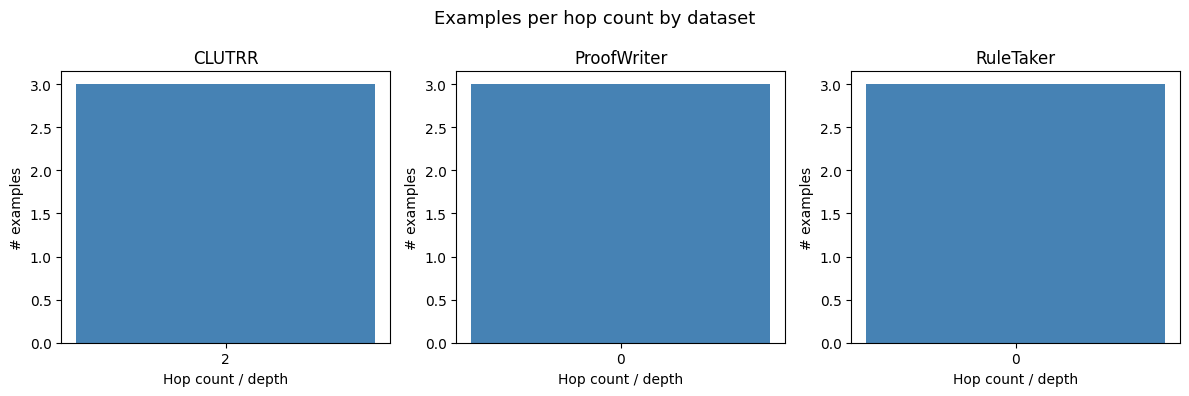

In [9]:
# Summary table
print(f"{'Dataset':<15} {'Count':>6} {'Domain':<15} {'Answer types'}")
print("-" * 60)
for src, src_examples in sorted(by_src.items()):
    domain = src_examples[0]["metadata_domain"]
    answers = sorted(set(ex["output"] for ex in src_examples))
    print(f"{src:<15} {len(src_examples):>6} {domain:<15} {answers}")

print(f"\nTotal: {len(all_examples)} examples across {len(by_src)} datasets")

# Hop count distribution
fig, axes = plt.subplots(1, len(by_src), figsize=(12, 4))
for ax, (src, src_examples) in zip(axes, sorted(by_src.items())):
    hop_counts = defaultdict(int)
    for ex in src_examples:
        hop_counts[ex["metadata_hop_count"]] += 1
    hops = sorted(hop_counts)
    counts = [hop_counts[h] for h in hops]
    ax.bar([str(h) for h in hops], counts, color="steelblue")
    ax.set_title(src)
    ax.set_xlabel("Hop count / depth")
    ax.set_ylabel("# examples")

plt.suptitle("Examples per hop count by dataset", fontsize=13)
plt.tight_layout()
plt.show()